Header version: 4
Header-reported offset: 58 bytes
Candidate offset being tested: 16 bytes
Candidate pattern count: 901,901
Pattern size (H × W): 120 × 120
Data type: uint16
The full dataset has NOT been loaded into RAM.


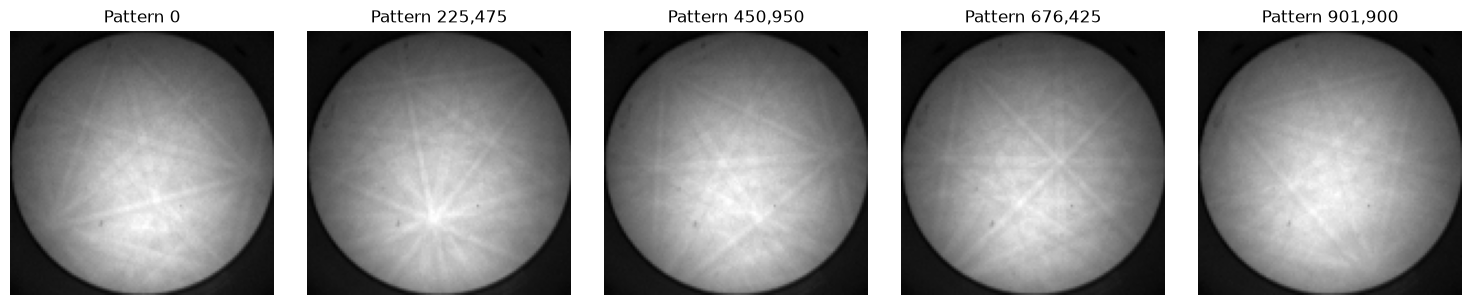

In [11]:
from pathlib import Path
import struct
import numpy as np
import matplotlib.pyplot as plt

up2_path = Path("data/718RX_1um_120x120.up2").expanduser().resolve()

with open(up2_path, "rb") as f:
    version, W, H, header_offset = struct.unpack("<4I", f.read(16))

# Candidate layout inferred from YOUR file's size and header bytes
offset = 16
dtype = np.dtype("<u2")
bytes_per_pattern = H * W * dtype.itemsize

N, remainder = divmod(
    up2_path.stat().st_size - offset,
    bytes_per_pattern,
)

if min(H, W, N) <= 0 or remainder != 0:
    raise ValueError("File does not fit the proposed 16-byte-header layout.")

patterns = np.memmap(
    up2_path,
    dtype=dtype,
    mode="r",
    offset=offset,
    shape=(N, H, W),
)

print(f"Header version: {version}")
print(f"Header-reported offset: {header_offset} bytes")
print(f"Candidate offset being tested: {offset} bytes")
print(f"Candidate pattern count: {N:,}")
print(f"Pattern size (H × W): {H} × {W}")
print(f"Data type: {dtype}")
print("The full dataset has NOT been loaded into RAM.")

# Inspect patterns throughout the file, including both ends
preview_ids = np.linspace(0, N - 1, 5, dtype=np.int64)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for ax, pattern_id in zip(axes, preview_ids):
    image = np.array(patterns[int(pattern_id)], copy=True)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Pattern {pattern_id:,}")
    ax.axis("off")

plt.tight_layout()
plt.show()